17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7300 - loss: 0.5116 - val_accuracy: 0.8281 - val_loss: 0.3998
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.8566 - loss: 0.3400 - val_accuracy: 0.8235 - val_loss: 0.3927
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.9120 - loss: 0.2257 - val_accuracy: 0.8211 - val_loss: 0.4704
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8211 - loss: 0.4704
RNN Accuracy: 0.8211
RNN Training Time: 59.45 seconds


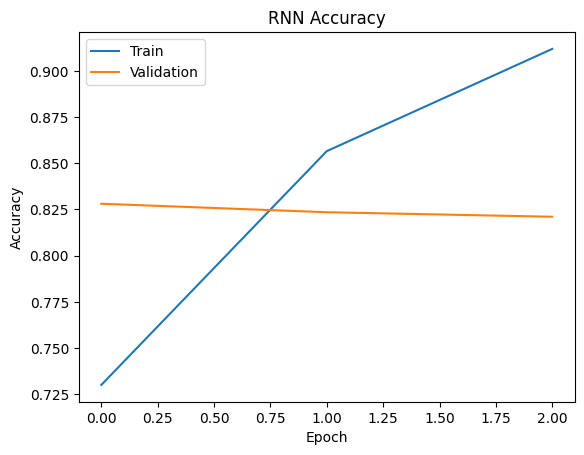

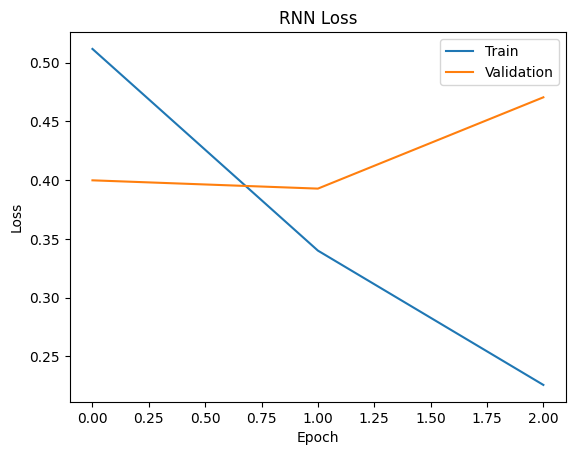


Training LSTM...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.7946 - loss: 0.4337 - val_accuracy: 0.8476 - val_loss: 0.3494
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 97ms/step - accuracy: 0.8734 - loss: 0.2991 - val_accuracy: 0.8461 - val_loss: 0.3498
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.9017 - loss: 0.2414 - val_accuracy: 0.8414 - val_loss: 0.3914
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8414 - loss: 0.3914
LSTM Accuracy: 0.8414
LSTM Training Time: 116.99 seconds


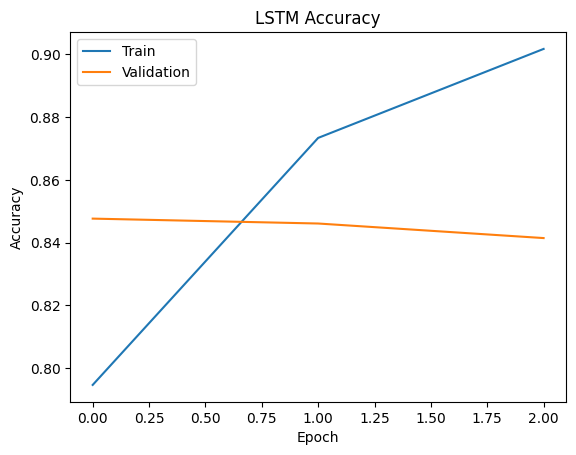

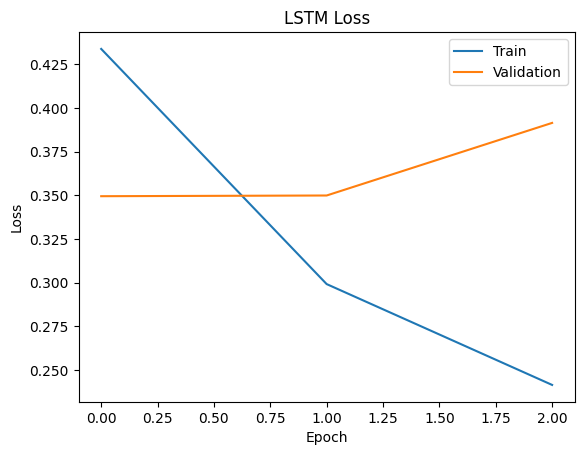


Training GRU...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 101ms/step - accuracy: 0.7810 - loss: 0.4443 - val_accuracy: 0.8447 - val_loss: 0.3547
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.8752 - loss: 0.3009 - val_accuracy: 0.8422 - val_loss: 0.3611
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 100ms/step - accuracy: 0.9014 - loss: 0.2437 - val_accuracy: 0.8552 - val_loss: 0.3439
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8552 - loss: 0.3439
GRU Accuracy: 0.8552
GRU Training Time: 120.06 seconds


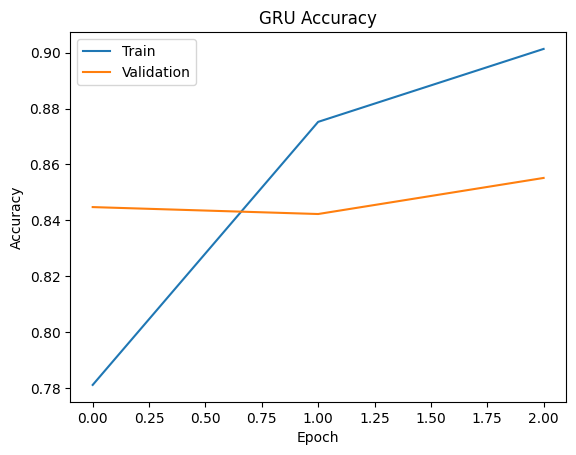

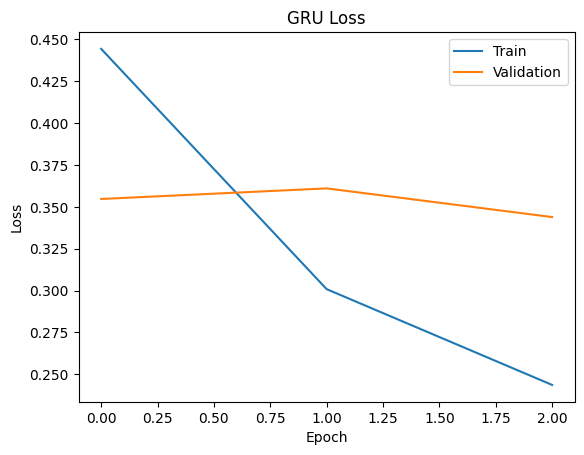


=== FINAL COMPARISON ===
RNN  -> Acc: 0.8211, Time: 59.45
LSTM -> Acc: 0.8414, Time: 116.99
GRU  -> Acc: 0.8552, Time: 120.06


In [ ]:
# LAB 4: RNN vs LSTM vs GRU Comparison WITH GRAPHS

import numpy as np
import time
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset
vocab_size = 5000
max_len = 100

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# Function to build model
def build_model(layer):
    model = Sequential()
    model.add(Embedding(vocab_size, 128, input_length=max_len))
    model.add(layer)
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Function to plot graphs
def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])
    plt.show()

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'])
    plt.show()

# Train and evaluate function
def train_model(model, name):
    print(f"\nTraining {name}...")
    start = time.time()

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_data=(x_test, y_test),
        verbose=1
    )

    end = time.time()
    loss, acc = model.evaluate(x_test, y_test)

    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} Training Time: {end - start:.2f} seconds")

    # Plot graphs
    plot_history(history, name)

    return acc, end - start

# Models
rnn_model = build_model(SimpleRNN(64))
lstm_model = build_model(LSTM(64))
gru_model = build_model(GRU(64))

# Run all
rnn_acc, rnn_time = train_model(rnn_model, "RNN")
lstm_acc, lstm_time = train_model(lstm_model, "LSTM")
gru_acc, gru_time = train_model(gru_model, "GRU")

# Final Comparison
print("\n=== FINAL COMPARISON ===")
print(f"RNN  -> Acc: {rnn_acc:.4f}, Time: {rnn_time:.2f}")
print(f"LSTM -> Acc: {lstm_acc:.4f}, Time: {lstm_time:.2f}")
print(f"GRU  -> Acc: {gru_acc:.4f}, Time: {gru_time:.2f}")